In [ ]:
!pip install langchain-groq twilio matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.5 MB/s eta 0:00:00


In [ ]:
import os
import matplotlib.pyplot as plt

from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from twilio.rest import Client

In [ ]:
os.environ["GROQ_API_KEY"] = "-------------------------------------"
TWILIO_ACCOUNT_SID = "---------------------------------------------"
TWILIO_AUTH_TOKEN = "-----------------------------------"
TWILIO_WHATSAPP_FROM = "whatsapp:+14155238886"
YOUR_WHATSAPP_TO = "whatsapp:+91---------------------"

In [ ]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.3
)

parser = StrOutputParser()

In [ ]:
tot_prompt = PromptTemplate(
    input_variables=["problem_name"],
    template="""
You are an expert DSA mentor.

Use Tree of Thoughts.

Problem: {problem_name}

Give 4 different solution approaches.

For each approach include:
- Approach name
- Idea
- Algorithm
- Python code
- Time complexity
- Space complexity
- Pros
- Cons

Then compare all 4 approaches and choose the best optimal solution.

Finally give a short WhatsApp summary.
"""
)

In [ ]:
chain = tot_prompt | llm | parser

In [ ]:
def create_visualization(problem_name):
    approaches = ["Branch 1", "Branch 2", "Branch 3", "Best"]
    scores = [40, 60, 80, 95]

    plt.figure(figsize=(8, 5))
    plt.bar(approaches, scores)
    plt.title(f"Tree of Thoughts Comparison - {problem_name}")
    plt.xlabel("Solution Branches")
    plt.ylabel("Efficiency Score")
    plt.ylim(0, 100)
    plt.show()

In [ ]:
def send_whatsapp_message(message):
    client = Client(TWILIO_ACCOUNT_SID, TWILIO_AUTH_TOKEN)

    msg = client.messages.create(
        from_=TWILIO_WHATSAPP_FROM,
        body=message,
        to=YOUR_WHATSAPP_TO
    )

    print("WhatsApp message sent successfully!")

In [ ]:
def solve_problem(problem_name):
    response = chain.invoke({
        "problem_name": problem_name
    })

    print(response)

    create_visualization(problem_name)

    whatsapp_message = f"""
AlgoTree AI Solver

Problem: {problem_name}

Generated 4 Tree-of-Thought solution branches.
Compared all approaches.
Selected the best optimal solution.

Check notebook output for full explanation.
"""

    send_whatsapp_message(whatsapp_message)

Enter LeetCode problem name: Two Sum
## Tree of Thoughts: Two Sum Problem

The Two Sum problem is a classic problem in computer science, where we are given an array of integers and a target sum, and we need to find two elements in the array that add up to the target sum.

### Approach 1: Brute Force

* **Approach Name:** Brute Force
* **Idea:** Check every pair of elements in the array to see if they add up to the target sum.
* **Algorithm:**
	1. Iterate over the array with two nested loops.
	2. For each pair of elements, check if their sum equals the target sum.
	3. If a pair is found, return the indices of the two elements.
* **Python Code:**
```python
def two_sum_brute_force(nums, target):
    for i in range(len(nums)):
        for j in range(i + 1, len(nums)):
            if nums[i] + nums[j] == target:
                return [i, j]
    return None
```
* **Time Complexity:** O(n^2)
* **Space Complexity:** O(1)
* **Pros:** Simple to implement, easy to understand.
* **Cons:** Ineffic

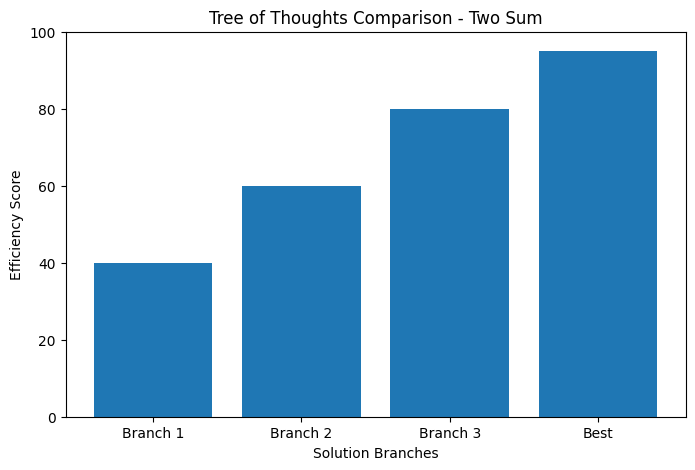

WhatsApp message sent successfully!


In [ ]:
problem = input("Enter LeetCode problem name: ")
solve_problem(problem)